In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from research_utils.metrics import classif_scores
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
predictions = pd.read_parquet("../experiments/test_pred.parquet")
cascade_predictions = pd.read_parquet("../experiments/test_cascade_pred.parquet")
test_predictions = pd.concat([predictions, cascade_predictions], axis=1)

test_predictions.head()

,gender_true,age_true,multi_true,length_true,rf_gender_pred_label,rf_gender_pred_proba_0,rf_gender_pred_proba_1,gbm_gender_pred_label,gbm_gender_pred_proba_0,gbm_gender_pred_proba_1,...,cascade_svc_poly_lr_gender_pred_proba_1,cascade_svc_poly_lr_age_pred_proba_0,cascade_svc_poly_lr_age_pred_proba_1,cascade_nb_gbm_gender_pred_label,cascade_nb_gbm_age_pred_label,cascade_nb_gbm_multi_label,cascade_nb_gbm_gender_pred_proba_0,cascade_nb_gbm_gender_pred_proba_1,cascade_nb_gbm_age_pred_proba_0,cascade_nb_gbm_age_pred_proba_1
11491,0,1,1,0,0,0.722885,0.277115,0,0.622072,0.377928,...,0.342949,0.290285,0.709715,0,1,1,0.973803,0.026197,0.320239,0.679761
8260,1,0,2,0,1,0.395532,0.604468,0,0.573884,0.426116,...,0.608654,0.555624,0.444376,1,0,2,0.238184,0.761816,0.581323,0.418677
10613,0,1,1,1,1,0.499780,0.500220,0,0.588066,0.411934,...,0.408485,0.274983,0.725017,0,1,1,0.991838,0.008162,0.068983,0.931017
2331,1,1,3,1,1,0.421016,0.578984,1,0.300303,0.699697,...,0.664625,0.342776,0.657224,1,0,2,0.427523,0.572477,0.832610,0.167390
11339,0,1,1,0,0,0.551578,0.448422,0,0.616277,0.383723,...,0.335017,0.292939,0.707061,0,1,1,0.904534,0.095466,0.061570,0.938430


In [3]:
profile_predictions = pd.DataFrame({
    "multi_true": test_predictions["multi_true"],
    "gender_true": test_predictions["gender_true"],
    "age_true": test_predictions["age_true"],
    "length_type": test_predictions["length_true"],
})

multi_columns = test_predictions.columns[test_predictions.columns.str.endswith("multi_label")]
multi_columns_mapper = { col: col[:-len("_multi_label")] for col in multi_columns }
flat_columns = test_predictions.columns[test_predictions.columns.str.contains("flat_pred_label")]
flat_columns_mapper = { col: f"flat_{col[:-len("_flat_pred_label")]}" for col in flat_columns }


profile_predictions[multi_columns] = test_predictions[multi_columns]
profile_predictions[flat_columns] = test_predictions[flat_columns]

profile_predictions.rename(columns=multi_columns_mapper, inplace=True)
profile_predictions.rename(columns=flat_columns_mapper, inplace=True)
profile_predictions.head()

,multi_true,gender_true,age_true,length_type,cascade_svc_poly_gbm,cascade_svc_poly_svc_rbf,cascade_svc_poly_lr,cascade_nb_gbm,flat_rf,flat_gbm,flat_lr,flat_nb,flat_knn,flat_mlp,flat_svc_linear,flat_svc_poly,flat_svc_rbf
11491,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1
8260,2,1,0,0,2,2,2,2,2,1,2,2,2,2,3,3,3
10613,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2331,3,1,1,1,2,2,3,2,3,2,1,1,1,3,3,3,1
11339,1,0,1,0,1,1,1,1,1,1,1,1,2,1,1,0,1


In [ ]:
women = profile_predictions[profile_predictions['gender_true'] == 0]
men = profile_predictions[profile_predictions['gender_true'] == 1]
young = profile_predictions[profile_predictions['age_true'] == 0]
old = profile_predictions[profile_predictions['age_true'] == 1]
short = profile_predictions[profile_predictions['length_type'] == 0]
long = profile_predictions[profile_predictions['length_type'] == 1]

dfs = [
    ("all", profile_predictions),
    ("women", women),
    ("men", men),
    ("young", young),
    ("old", old),
    ("short", short),
    ("long", long),
]

def get_scores_by_subsamples(target, models):
    scores = []

    for name, df in dfs:
        df_scores = get_models_scores(df, target, models)
        df_scores = df_scores.reset_index().rename(columns={'index': 'model'})
        df_scores['subsample'] = name
        scores.append(df_scores)
        
    return pd.concat(scores, axis=0, ignore_index=True)

def get_models_scores(df, target, models):
    all_scores_list = []
    
    for col, _ in models:
        all_scores_list.append(classif_scores, df[target], df[col])
    
    return pd.DataFrame(all_scores_list, index=models)

## Базовая модель


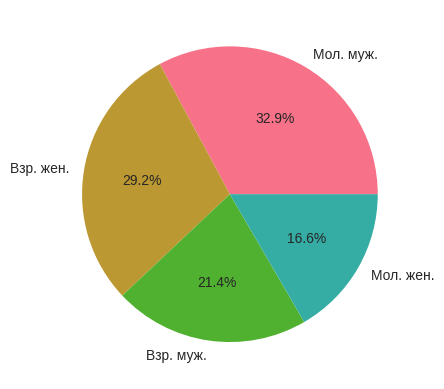

In [56]:
labels = { 0: 'Мол. жен.', 1: 'Взр. жен.', 2: 'Мол. муж.', 3: 'Взр. муж.' }

profiles = profile_predictions['multi_true'].value_counts().rename(index=labels)
profiles.plot(kind='pie', autopct='%1.1f%%')
plt.show()

В данных имеется небольшой дисбаланс. Меньше всего молодых женщин, больше всего - молодых мужчин. Общее число мужчин слегка больше женщин

Определим точность базовую модель относительно тестовых данных:
- Полный профиль = 32.9% (Всегда молодой мужчина)

## Прогнозирование профиля

In [ ]:
multi_columns = profile_predictions.columns[profile_predictions.columns.str.contains('flat_') | profile_predictions.columns.str.contains('cascade_')]

profile_model_scores_df = get_scores_by_subsamples('multi_true', multi_columns)
profile_model_scores_df.head()

,model,accuracy,precision,recall,f1,subsample
0,cascade_svc_poly_gbm,0.436643,0.417455,0.436643,0.410520,all
1,cascade_svc_poly_svc_rbf,0.445783,0.431273,0.445783,0.410952,all
2,cascade_svc_poly_lr,0.435812,0.409313,0.435812,0.395543,all
3,cascade_nb_gbm,0.402991,0.381309,0.402991,0.376607,all
4,flat_rf,0.417117,0.405856,0.417117,0.406082,all


### Оценка на всех данных

In [8]:
all_scores = profile_model_scores_df[profile_model_scores_df['subsample'] == 'all']
all_scores.drop(columns=["subsample"])

,model,accuracy,precision,recall,f1
0,cascade_svc_poly_gbm,0.436643,0.417455,0.436643,0.410520
1,cascade_svc_poly_svc_rbf,0.445783,0.431273,0.445783,0.410952
2,cascade_svc_poly_lr,0.435812,0.409313,0.435812,0.395543
3,cascade_nb_gbm,0.402991,0.381309,0.402991,0.376607
4,flat_rf,0.417117,0.405856,0.417117,0.406082
5,flat_gbm,0.440798,0.424664,0.440798,0.407562
6,flat_lr,0.435397,0.407355,0.435397,0.394120
7,flat_nb,0.405484,0.377353,0.405484,0.369938
8,flat_knn,0.419194,0.415912,0.419194,0.353835
9,flat_mlp,0.432073,0.394812,0.432073,0.373718


Все рассмотренные подходы превосходят наивный базовый уровень (32.9%), соответствующий стратегии "всегда молодой мужчина". 

Наилучший результат демонстрирует плоская модель `flat_svc_rbf` с точностью 45.0% и F1-мерой 0.420, что свидетельствует о её хорошей обобщающей способности при учёте дисбаланса классов. Близкие значения показывают каскадные комбинации `cascade_svc_poly_svc_rbf` (44.6% accuracy, 0.411 F1) и `cascade_svc_poly_gbm` (43.7% accuracy, 0.411 F1), а также плоские `flat_gbm` (44.1%) и `flat_lr` (43.5%). 

Каскад с наивным байесом (`cascade_nb_gbm`) уступает по точности (40.3%). 

Модели на основе случайного леса, kNN, MLP и полиномиального SVM показывают умеренную точность (41-43%), а линейный SVM оказался наименее эффективным (39.1%). Т

Таким образом, для решения задачи наиболее предпочтительными являются `flat_svc_rbf` и каскадные конфигурации с `svc_poly` на первом этапе, обеспечивающие баланс между точностью и стабильностью.

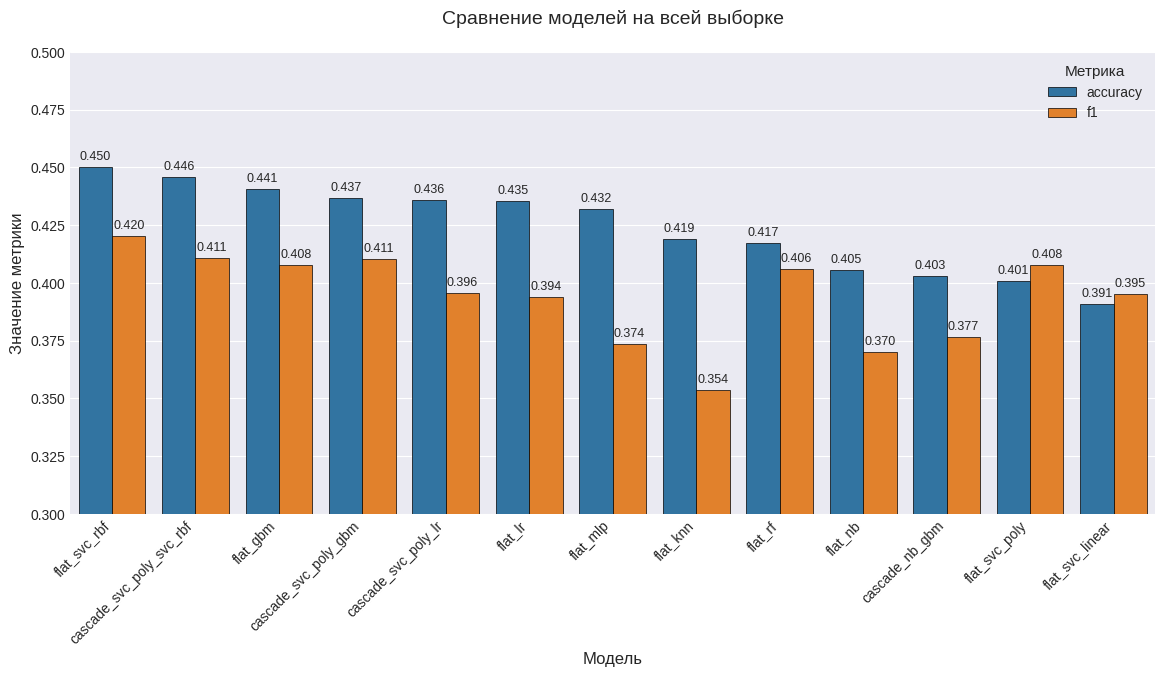

In [ ]:
all_melted = all_scores.sort_values('accuracy', ascending=False).reset_index(drop=True).melt(id_vars='model', value_vars=['accuracy', 'f1'], 
                             var_name='metric', value_name='score')

plt.figure(figsize=(14, 6))

ax = sns.barplot(data=all_melted, x='model', y='score', hue='metric', 
                 palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

ax.set_title('Сравнение моделей на всей выборке', fontsize=14, pad=20)
ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_ylim([0.3, 0.5])

ax.legend(title='Метрика', fontsize=10, title_fontsize=11)

plt.show()

### Лучшие модели по подвыборкам

In [29]:
top3 = profile_model_scores_df.groupby('subsample').apply(lambda x: x.nlargest(3, 'accuracy')[['model', 'accuracy']])
top3['rank'] = top3.groupby('subsample').cumcount() + 1
top3

model  accuracy  rank
subsample                                             
all       12              flat_svc_rbf  0.450353     1
          1   cascade_svc_poly_svc_rbf  0.445783     2
          5                   flat_gbm  0.440798     3
long      78      cascade_svc_poly_gbm  0.434529     1
          90              flat_svc_rbf  0.433695     2
          80       cascade_svc_poly_lr  0.432861     3
men       38              flat_svc_rbf  0.475862     1
          35                  flat_mlp  0.455172     2
          31                  flat_gbm  0.449808     3
old       53  cascade_svc_poly_svc_rbf  0.439967     1
          52      cascade_svc_poly_gbm  0.425987     2
          57                  flat_gbm  0.421053     3
short     77              flat_svc_rbf  0.466887     1
          66  cascade_svc_poly_svc_rbf  0.461921     2
          70                  flat_gbm  0.457781     3
women     14  cascade_svc_poly_svc_rbf  0.450998     1
          15       cascade_svc_poly_lr  0.447368     2
          13      cascade_svc_poly_gbm  0.445554     3
young     51              flat_svc_rbf  0.506297     1
          48                  flat_mlp  0.488665     2
          47                  flat_knn  0.470193     3

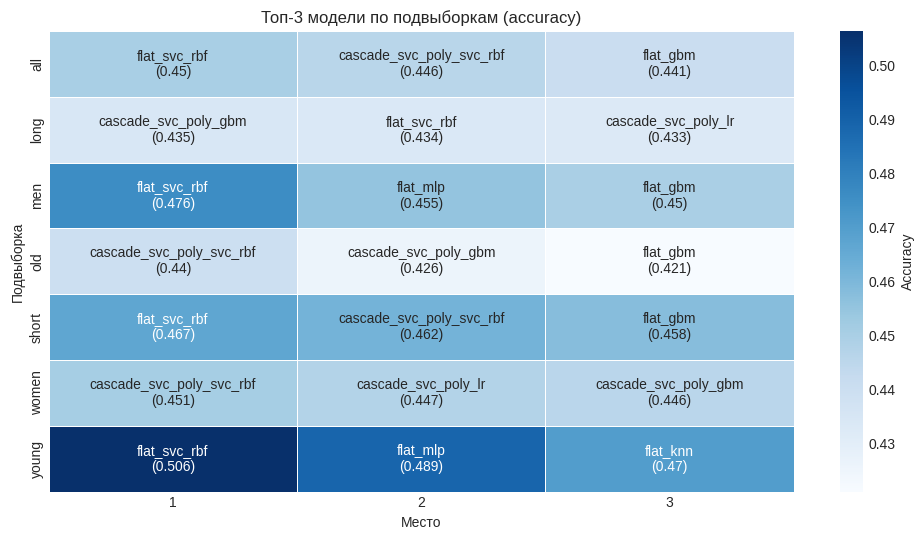

In [33]:
top3_plt = top3.reset_index(level=0)           

pivot_models = top3_plt.pivot(index='subsample', columns='rank', values='model')
pivot_acc = top3_plt.pivot(index='subsample', columns='rank', values='accuracy')

annot_matrix = pivot_models.copy()
for r in [1,2,3]:
    annot_matrix[r] = pivot_models[r] + '\n(' + pivot_acc[r].round(3).astype(str) + ')'

plt.figure(figsize=(10, len(pivot_models)*0.5 + 2))
sns.heatmap(pivot_acc, annot=annot_matrix, fmt='', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Accuracy'}, annot_kws={'size': 10})
plt.xlabel('Место')
plt.ylabel('Подвыборка')
plt.title('Топ-3 модели по подвыборкам (accuracy)')
plt.tight_layout()
plt.show()

Плоская модель `flat_svc_rbf` наиболее универсальна: она занимает первые места на общей выборке, среди мужчин, молодых и коротких текстов, а также вторые места на длинных текстах, демонстрируя стабильно высокое качество (45.0% на всех данных, 50.6% на молодых). 

Каскадные конфигурации, особенно `cascade_svc_poly_svc_rbf`, показывают преимущество на группах, где плоские модели уступают: они лидируют на женщинах (45.1%) и взрослых (44.0%), а также входят в топ-3 на коротких и длинных текстах.  

При этом на мужчинах каскадные модели уступают плоским (первые места у `flat_svc_rbf` и `flat_mlp`), что указывает на специфику учёта пола в каскаде: первый этап может вносить ошибки, снижая итоговую точность на доминирующей группе. 

На молодых, где дисбаланс максимален в пользу молодых мужчин, лучшие результаты достигаются плоскими моделями (`flat_svc_rbf`, `flat_mlp`, `flat_knn`), что подтверждает их способность эффективно использовать общие признаки без дополнительного разделения. 

Таким образом, для максимальной обобщаемости на разнородной аудитории рекомендуется комбинировать подходы: использовать `flat_svc_rbf` как базовое решение, а при необходимости повышения точности на женщинах и пожилых - каскад `svc_poly_svc_rbf`.

### Оценка смещения моделей на подвыборках

In [35]:
pivot_acc = profile_model_scores_df.pivot(index='model', columns='subsample', values='accuracy')
pivot_acc

subsample,all,long,men,old,short,women,young
model,,,,,,,
cascade_nb_gbm,0.402991,0.396163,0.394636,0.389803,0.409768,0.412886,0.416457
cascade_svc_poly_gbm,0.436643,0.434529,0.429119,0.425987,0.438742,0.445554,0.447523
cascade_svc_poly_lr,0.435812,0.432861,0.426054,0.418586,0.438742,0.447368,0.453401
cascade_svc_poly_svc_rbf,0.445783,0.429525,0.441379,0.439967,0.461921,0.450998,0.451721
flat_gbm,0.440798,0.423686,0.449808,0.421053,0.457781,0.430127,0.460957
flat_knn,0.419194,0.410342,0.434483,0.369243,0.427980,0.401089,0.470193
flat_lr,0.435397,0.426188,0.429885,0.416941,0.444536,0.441924,0.454240
flat_mlp,0.432073,0.428691,0.455172,0.376645,0.435430,0.404719,0.488665
flat_nb,0.405484,0.396997,0.402299,0.365132,0.413907,0.409256,0.446683


In [42]:
diff_dfs = []

pairs = [('men', 'women', 'gender'), ('young', 'old', 'age'), ('short', 'long', 'length')]
for group1, group2, pairname in pairs:
    if group1 in pivot_acc.columns and group2 in pivot_acc.columns:
        diff = pivot_acc[group1] - pivot_acc[group2]
        diff_df = diff.reset_index()
        diff_df.columns = ['model', f'diff_{pairname}']
        diff_dfs.append(diff_df)

diff_summary = diff_dfs[0]
for df in diff_dfs[1:]:
    diff_summary = diff_summary.merge(df, on='model')

diff_summary


,model,diff_gender,diff_age,diff_length
0,cascade_nb_gbm,-0.018250,0.026654,0.013605
1,cascade_svc_poly_gbm,-0.016435,0.021536,0.004213
2,cascade_svc_poly_lr,-0.021315,0.034815,0.005881
3,cascade_svc_poly_svc_rbf,-0.009619,0.011754,0.032396
4,flat_gbm,0.019681,0.039905,0.034095
5,flat_knn,0.033394,0.100950,0.017638
6,flat_lr,-0.012039,0.037299,0.018348
7,flat_mlp,0.050454,0.112020,0.006740
8,flat_nb,-0.006957,0.081552,0.016910
9,flat_rf,-0.034039,0.041906,0.015161


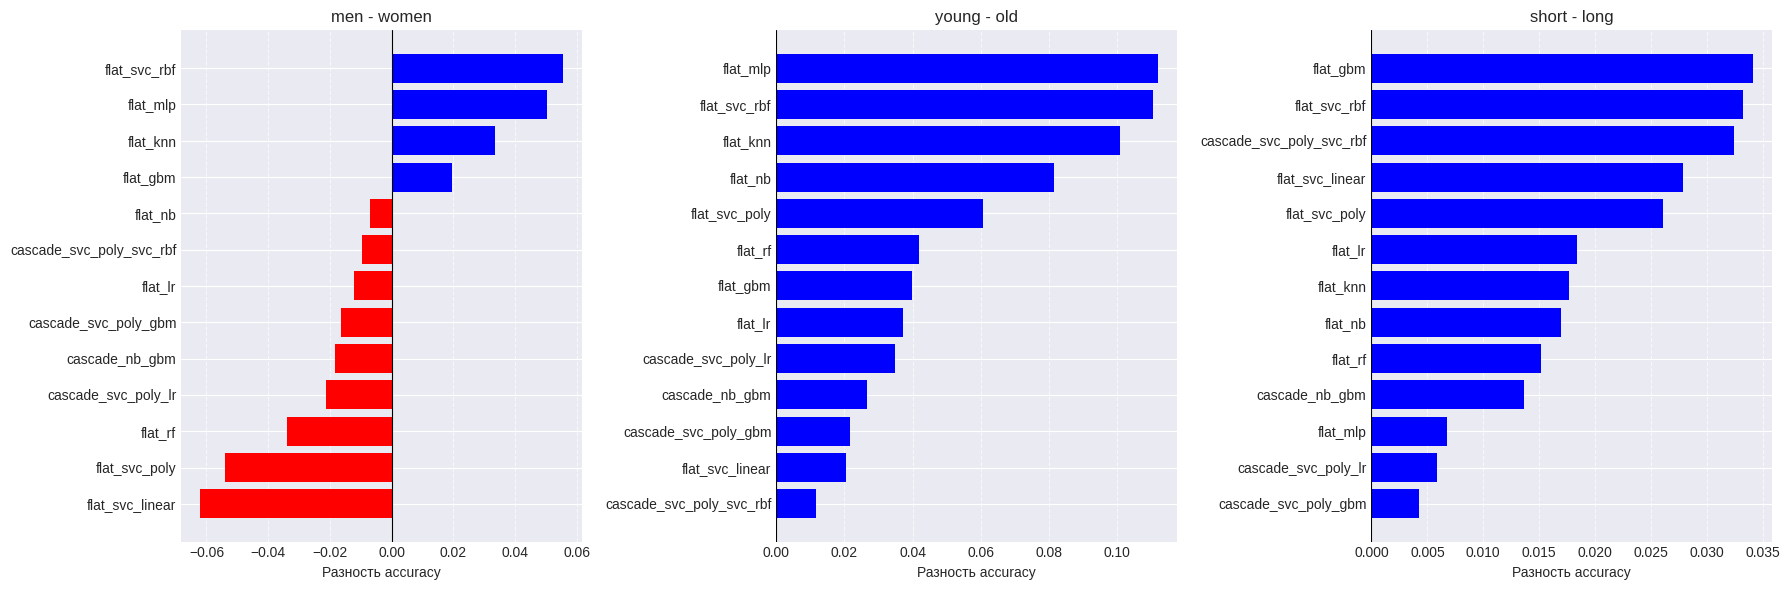

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [('gender', 'men - women'), ('age', 'young - old'), ('length', 'short - long')]

for ax, (col, title) in zip(axes, pairs):
    sorted_df = diff_summary.sort_values(f'diff_{col}', ascending=True)
    models = sorted_df['model']
    diffs = sorted_df[f'diff_{col}']
    
    colors = ['red' if d < 0 else 'blue' for d in diffs]
    
    ax.barh(models, diffs, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Разность accuracy')
    ax.set_title(title)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Каскадные конфигурации систематически обеспечивают меньший дисбаланс по сравнению с плоскими моделями. 

Наименьшее смещение по полу демонстрирует `cascade_svc_poly_svc_rbf` (diff_gender = -0.0096), что означает практически равную точность на мужчинах и женщинах с незначительным преимуществом последних. Близкие к нулю значения также показывают `flat_nb` (-0.0070) и `cascade_svc_poly_gbm` (-0.0164). 

По возрасту все модели лучше работают на молодых, однако минимальный разрыв зафиксирован у `cascade_svc_poly_svc_rbf` (diff_age = 0.0118), тогда как плоские модели, такие как `flat_mlp` (0.112) и `flat_svc_rbf` (0.111), имеют сильное смещение в сторону молодых. 

По длине текста наименьшее смещение наблюдается у каскадных моделей: `cascade_svc_poly_gbm` (diff_length = 0.0042) и `cascade_svc_poly_lr` (0.0059), которые практически инвариантны к длине, тогда как плоские модели демонстрируют умеренный разброс (например, `flat_gbm` с уклоном в короткие, `cascade_svc_poly_svc_rbf` - в длинные).  

### Модель с максимальным минимальным качеством

In [46]:
min_acc = profile_model_scores_df.groupby('model')['accuracy'].min().sort_values(ascending=False)
min_acc

model
cascade_svc_poly_svc_rbf    0.429525
cascade_svc_poly_gbm        0.425987
flat_gbm                    0.421053
cascade_svc_poly_lr         0.418586
flat_lr                     0.416941
flat_rf                     0.396382
flat_svc_rbf                0.395559
cascade_nb_gbm              0.389803
flat_mlp                    0.376645
flat_svc_poly               0.370888
flat_knn                    0.369243
flat_nb                     0.365132
flat_svc_linear             0.362452
Name: accuracy, dtype: float64

In [ ]:
best_min_model = min_acc.idxmax()
best_min_value = min_acc.max()
print(f"Лучшая модель по критерию max-min: {best_min_model} (min accuracy = {best_min_value:.3f})")


Лучшая модель по критерию max-min: cascade_svc_poly_svc_rbf (min accuracy = 0.430)


### Матрица ошибок классификации

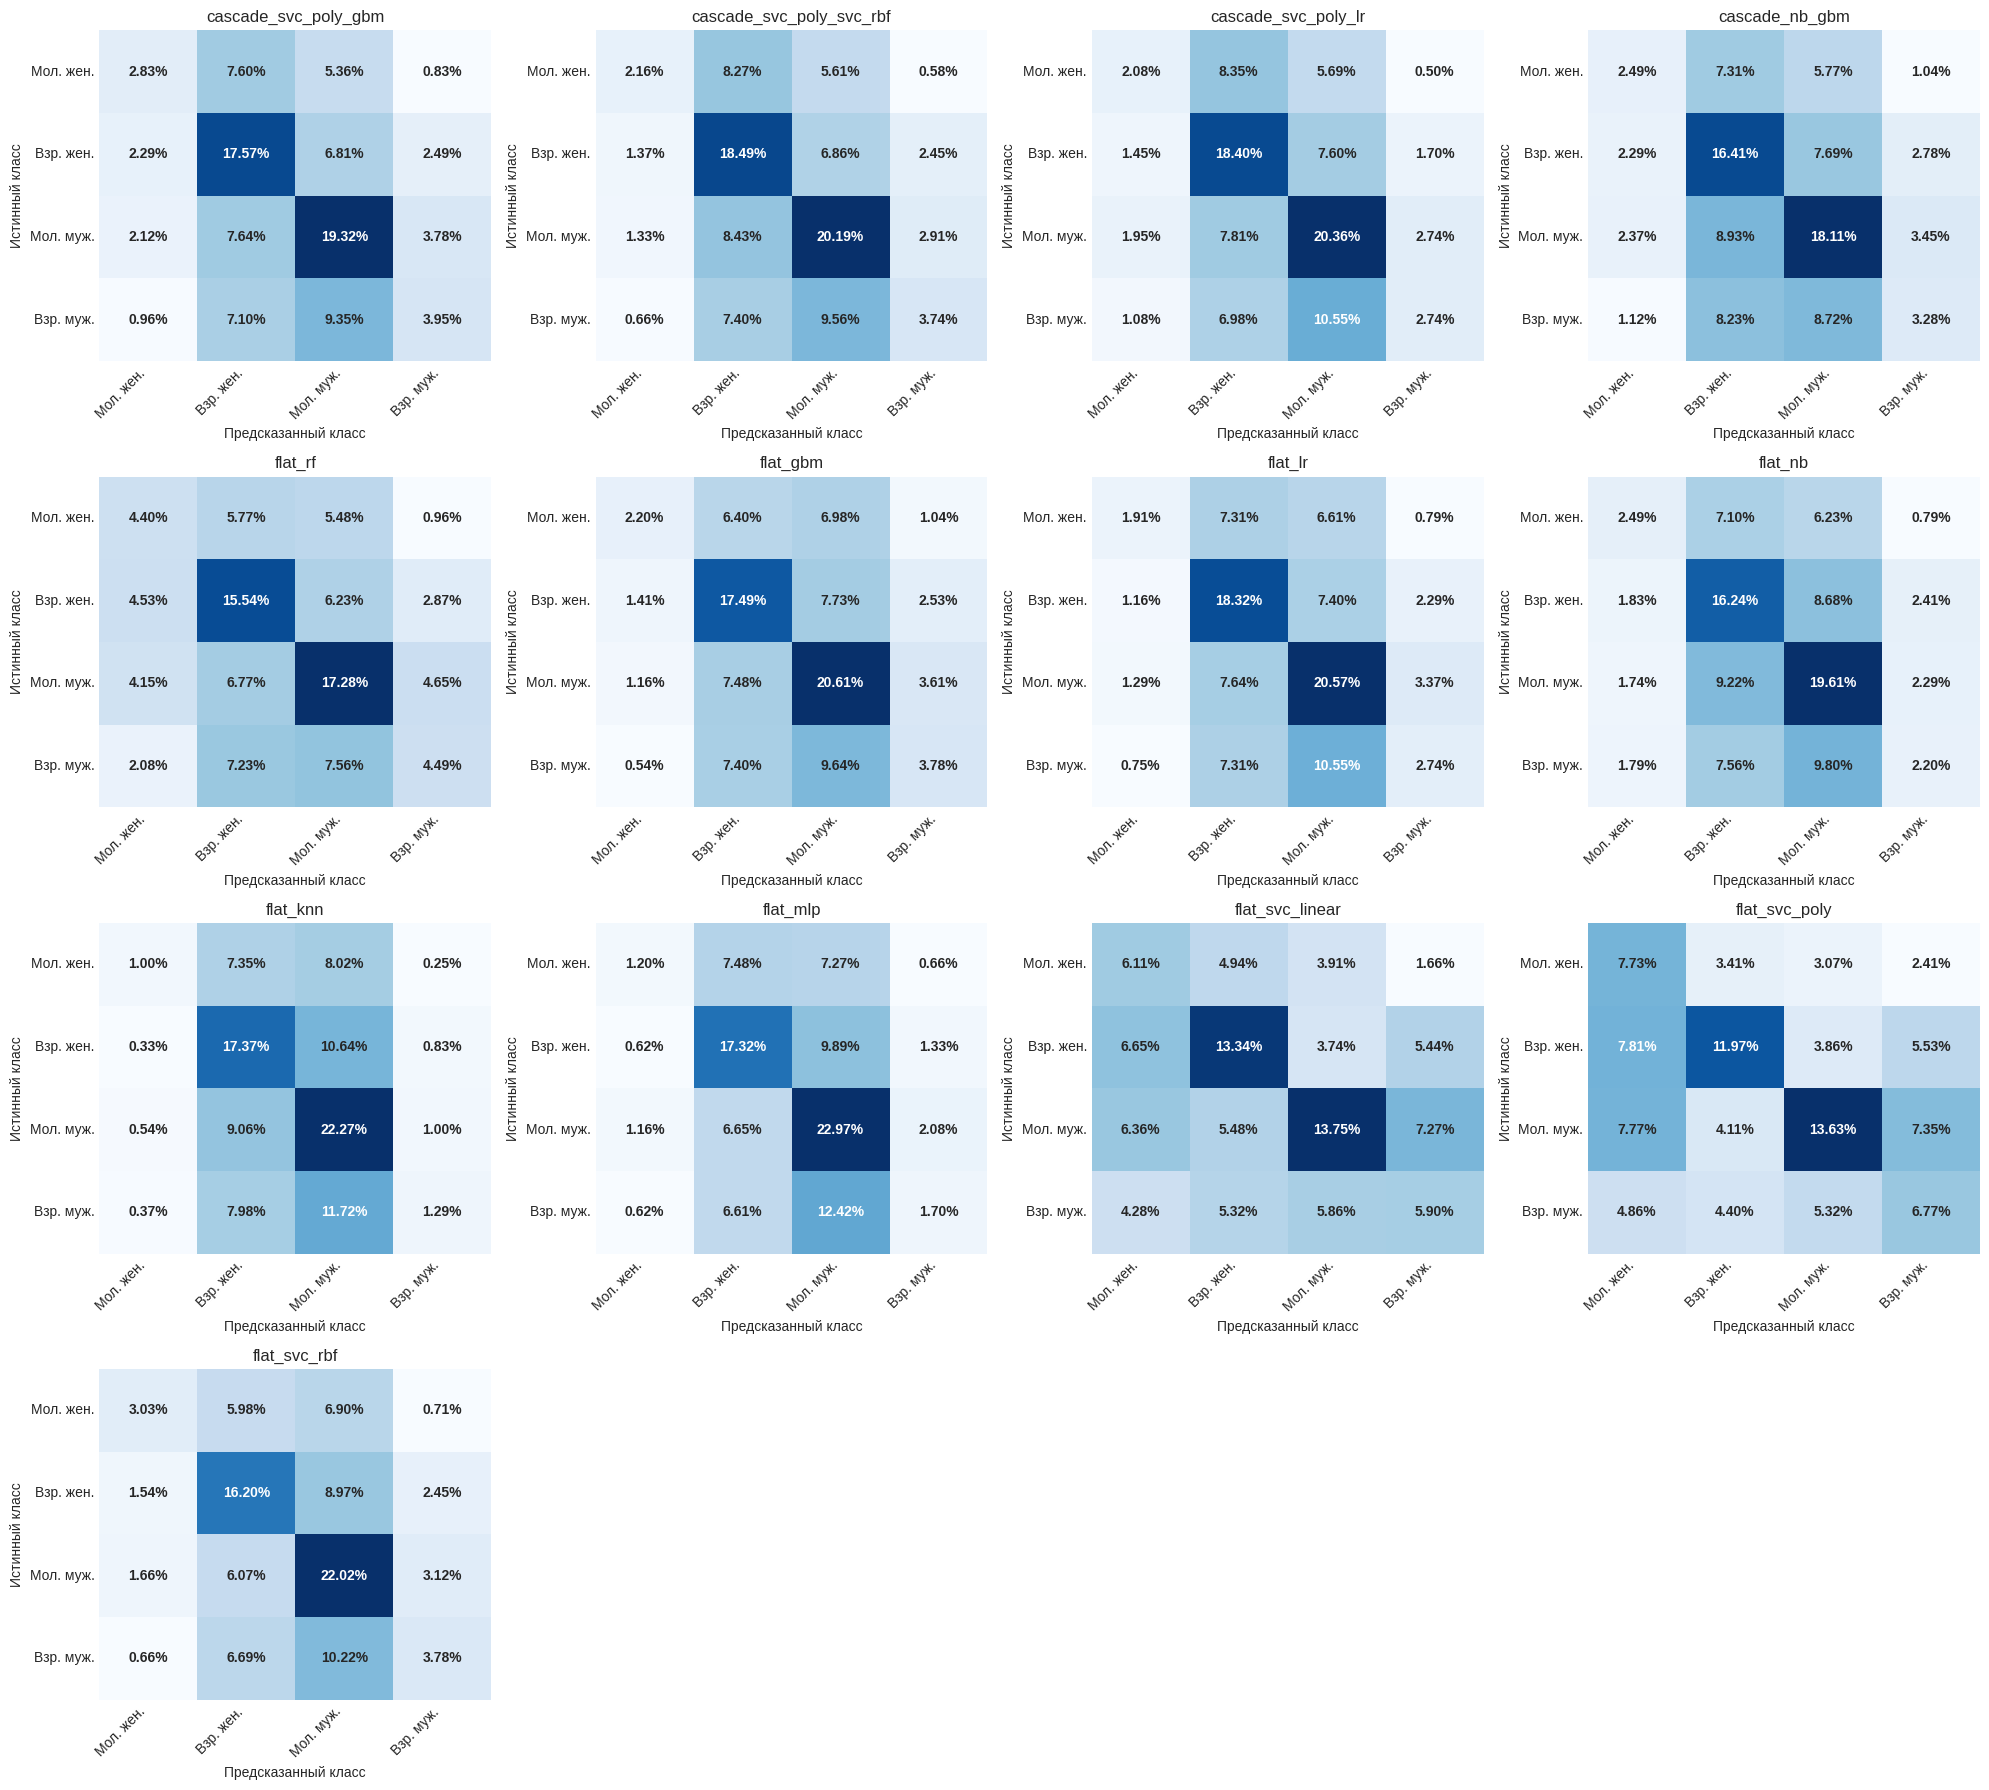

In [74]:
fig, axes = plt.subplots(4, 4, figsize=(20, 18)) 
axes = axes.flatten()

class_names = [labels[i] for i in range(4)] 

for idx, col in enumerate(multi_columns):
    ax = axes[idx]
    
    y_true = profile_predictions['multi_true']
    y_pred = profile_predictions[col]
    
    cm = confusion_matrix(y_true, y_pred, normalize="all")
    
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=ax, cbar=False,
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size': 10, 'weight': 'bold'})
    
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(class_names, rotation=0, fontsize=10)
    
    ax.set_title(f'{col}', fontsize=12)
    
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')

for idx in range(len(multi_columns), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Матрица ошибок подтверждает, что данные несбалансированы: класс "молодой мужчина" доминирует, а класс "молодая женщина" представлен минимально. 

Базовая стратегия "всегда предсказывать молодого мужчину" даёт точность 32.9%, и все модели лишь умеренно улучшают этот показатель (40–45% суммарной точности по диагонали). 

При этом систематически наблюдается смещение предсказаний в сторону доминирующего класса - большинство моделей склонны ошибочно классифицировать другие группы как молодых мужчин, что особенно критично для молодых женщин и взрослых мужчин, распознаваемых хуже всего.

Исключение составляют модели `flat_svc_poly` и `flat_svc_linear`, у которых на главной диагонали каждой строки матрицы ошибок стоят наибольшие значения. Это означает, что они правильно распознают каждый класс чаще, чем любой другой, и не игнорируют редкие группы. В частности, `flat_svc_poly` верно классифицирует 7.73% молодых женщин (против 2–3% у других моделей) и 11.97% взрослых женщин, сохраняя при этом приемлемую точность на мужчинах. Хотя их общая точность (40.1% и 39.1% соответственно) уступает каскадным конфигурациям, они обеспечивают наиболее сбалансированное распознавание по всем классам.

## Итоги

Все рассмотренные подходы превосходят наивный базовый уровень (32.9%), однако между ними наблюдаются чёткие различия в точности, смещении и специализации на отдельных подвыборках.

### Ключевые модели
- `flat_svc_rbf` – лучшая по общей точности (45.0%) и F1-мере (0.420). Наиболее универсальна: показывает первые места на общей выборке, среди мужчин, молодых и коротких текстах. Обладает умеренным смещением, но на женщинах и взрослых уступает каскадам.
- `cascade_svc_poly_svc_rbf` – наилучший каскад: лидирует на женщинах (45.1%) и взрослых (44.0%), имеет минимальное смещение по полу (разница точности между мужчинами и женщинами всего 0.0096) и возрасту (0.0118). Это самая устойчивая модель по критерию максимина (минимальная точность на худшей подвыборке – 43.0%).
- `flat_svc_poly` – обеспечивает наиболее сбалансированное распознавание всех четырёх классов: в отличие от большинства моделей, не игнорирует редкие группы (молодые женщины), правильно классифицируя их в 7.7% случаев против 2–3% у других. При меньшей общей точности (40.1%) она даёт наилучшую справедливость предсказаний.

### Рекомендации по применению
| Ситуация / Приоритет | Рекомендуемая модель | Обоснование |
|----------------------|----------------------|-------------|
| Максимальная общая точность на разнородной выборке | `flat_svc_rbf` | Лучшая accuracy на всех данных, хорошо работает на большинстве подвыборок (мужчины, молодые, короткие тексты). |
| Повышение качества на женщинах и взрослых, снижение смещения по полу/возрасту | `cascade_svc_poly_svc_rbf` | Лучшие результаты на этих группах, минимальный дисбаланс, высокая гарантия качества на любой подвыборке. |
| Справедливое распознавание редких классов (например, молодых женщин), если важна сбалансированность, а не только общая точность | `flat_svc_poly` и `flat_svc_linear` | Наиболее равномерно распределяет ошибки, не игнорирует меньшинства. |
| Если данные имеют перекос в сторону длинных текстов | `cascade_svc_poly_gbm` или `cascade_svc_poly_lr` | Эти каскады практически инвариантны к длине текста (минимальное смещение по длине). |
| Работа на коротких текстах | `flat_svc_rbf` или `flat_mlp` | Лучшие показатели на подвыборке short. |

Таким образом, для большинства практических сценариев оптимальным выбором является `flat_svc_rbf` как универсальное решение. Если же требуется нивелировать смещение и улучшить предсказания на женщинах и взрослых, стоит перейти на каскад `cascade_svc_poly_svc_rbf`. В задачах, где критически важно не потерять редкие категории, предпочтение следует отдать `flat_svc_poly`.